In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings

import CM4Xutils
import numpy as np
import pandas as pd
import xarray as xr
import xgcm
import xhistogram

import gsw, xwmt
import zarr

In [3]:
import cmocean
import matplotlib.colors as colors
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams.update({'font.size': 12})

In [4]:
xgcm.__version__, xwmt.__version__

('0.9.0', '0.1.0')

### Load data and create metadata structures

In [5]:
from common import *
grids = load_datasets()
grid = grids['CM4Xp125_forced']
ds = grid._ds

Inferring Z grid coordinate: depth `z_`
Inferring Z grid coordinate: depth `z_`


In [6]:
ds_outcrop = xr.open_dataset("../data/processed/layer_outcrop_frequencies_CM4Xp125_forced.nc")

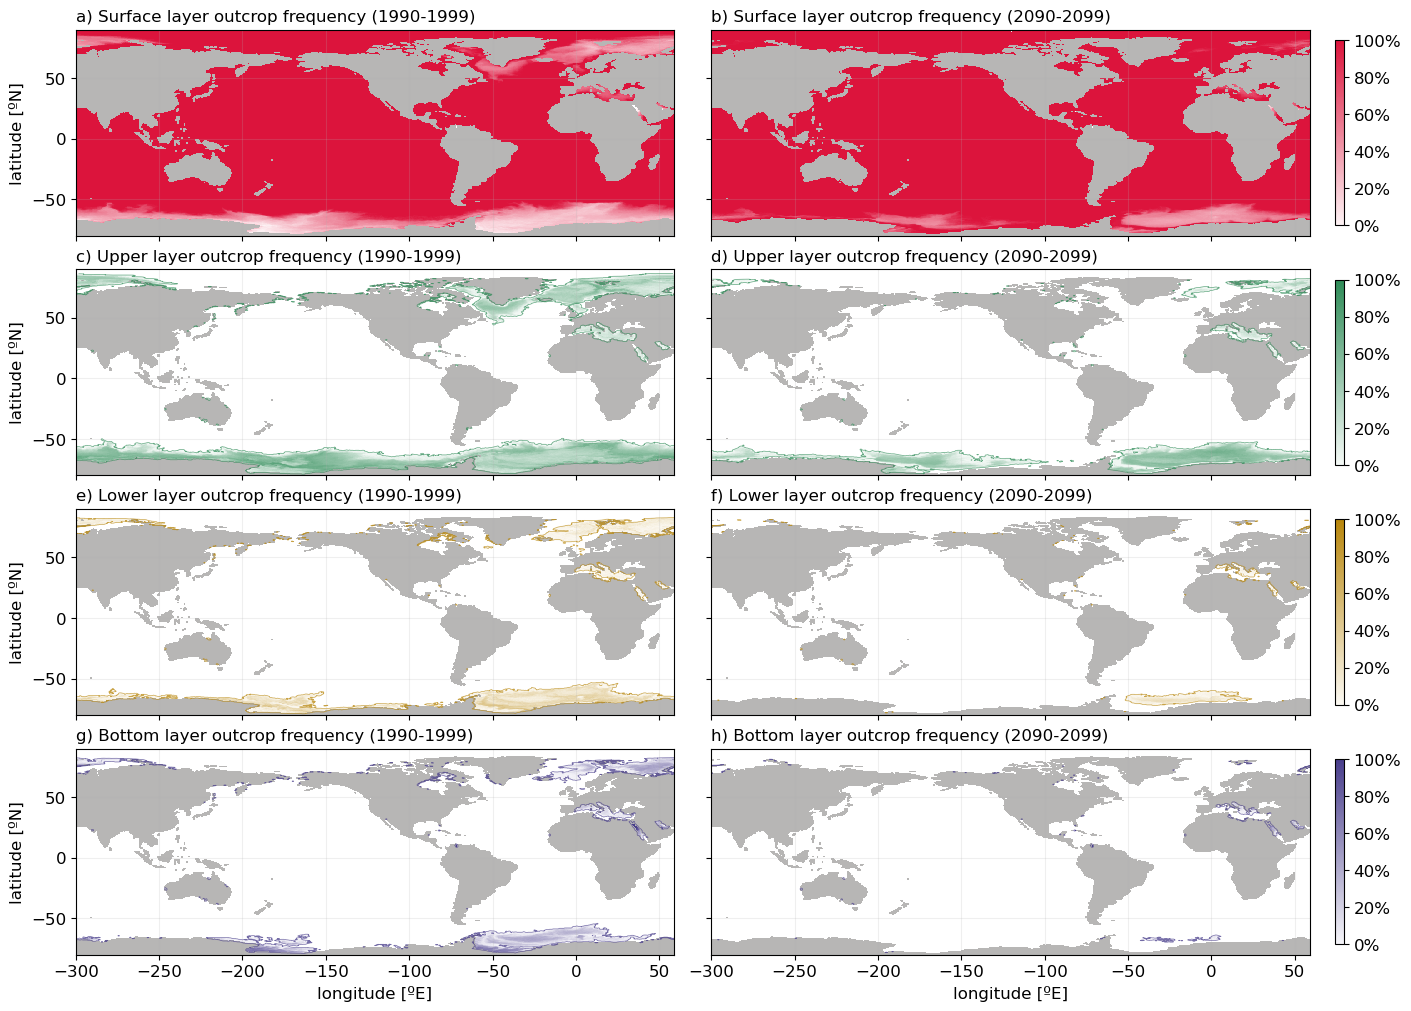

In [7]:
titles = [
    "a) Surface layer outcrop frequency (1990-1999)",
    "b) Surface layer outcrop frequency (2090-2099)",
    "c) Upper layer outcrop frequency (1990-1999)",
    "d) Upper layer outcrop frequency (2090-2099)",
    "e) Lower layer outcrop frequency (1990-1999)",
    "f) Lower layer outcrop frequency (2090-2099)",
    "g) Bottom layer outcrop frequency (1990-1999)",
    "h) Bottom layer outcrop frequency (2090-2099)",
]

fig, axes = plt.subplots(4,2,figsize=(14, 10), layout="constrained")

for r, start_year in enumerate([1990, 2090]):
    ds = ds_outcrop.sel(start_year=start_year)
    years = [str(start_year), str(ds.end_year.values)]
    
    for k, (rho2, color) in enumerate(zip(ds.rho2_moc_l, layer_colors)):
        ax = axes[k,r]
        outcrop_frequency = ds.outcrop_frequency.sel(rho2_moc_l=rho2)
        cm_tmp = cmap_offwhite_fade(layer_colors[k]).copy()
        cm_tmp.set_bad([0., 0., 0., 0.])
        pc = ax.pcolormesh(
            outcrop_frequency.geolon,
            outcrop_frequency.geolat,
            outcrop_frequency.where(outcrop_frequency!=0),
            cmap=cm_tmp,
            vmin=0, vmax=100
        )
        if k>0:
            ax.contour(
                outcrop_frequency.geolon,
                outcrop_frequency.geolat,
                outcrop_frequency.fillna(0.),
                levels = [1.e-3],
                linestyles="-", linewidths=0.5, colors=layer_colors[k], alpha=0.75,
            )
        ax.set_title(titles[r+k*2], loc="left", fontsize=12)
        if k==len(layer_colors)-1:
            ax.set_xlabel("longitude [ºE]")
        else:
            ax.set_xlabel("")
            ax.set_xticklabels([])
        ax.set_ylim(-80, 90)
        ax.set_xlim(-300, 59)
        ax.pcolor(
            ds.geolon,
            ds.geolat,
            ds.deptho.fillna(0.).where(ds.deptho.fillna(0.)==0.) + 1,
            cmap=cmocean.cm.gray,
            vmin=0, vmax=1.3
        )
        ax.grid(True, alpha=0.2)

        if r==1:
            cbar = fig.colorbar(pc, ax=axes[k, :], shrink=0.9, pad=0.02)
            cbar.set_ticks([0, 20, 40, 60, 80, 100])
            cbar.set_ticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])

        if r==0: 
            axes[k][0].set_ylabel("latitude [ºN]")
            axes[k][1].set_yticklabels([]);

plt.savefig("../figures/SFig4_layer_outcrops.png", dpi=400, bbox_inches="tight")

### Layer-wise inventory

In [8]:
ds_inv = xr.open_dataset("../data/processed/layer_cfc11_inventories_CM4Xp125_forced.nc")

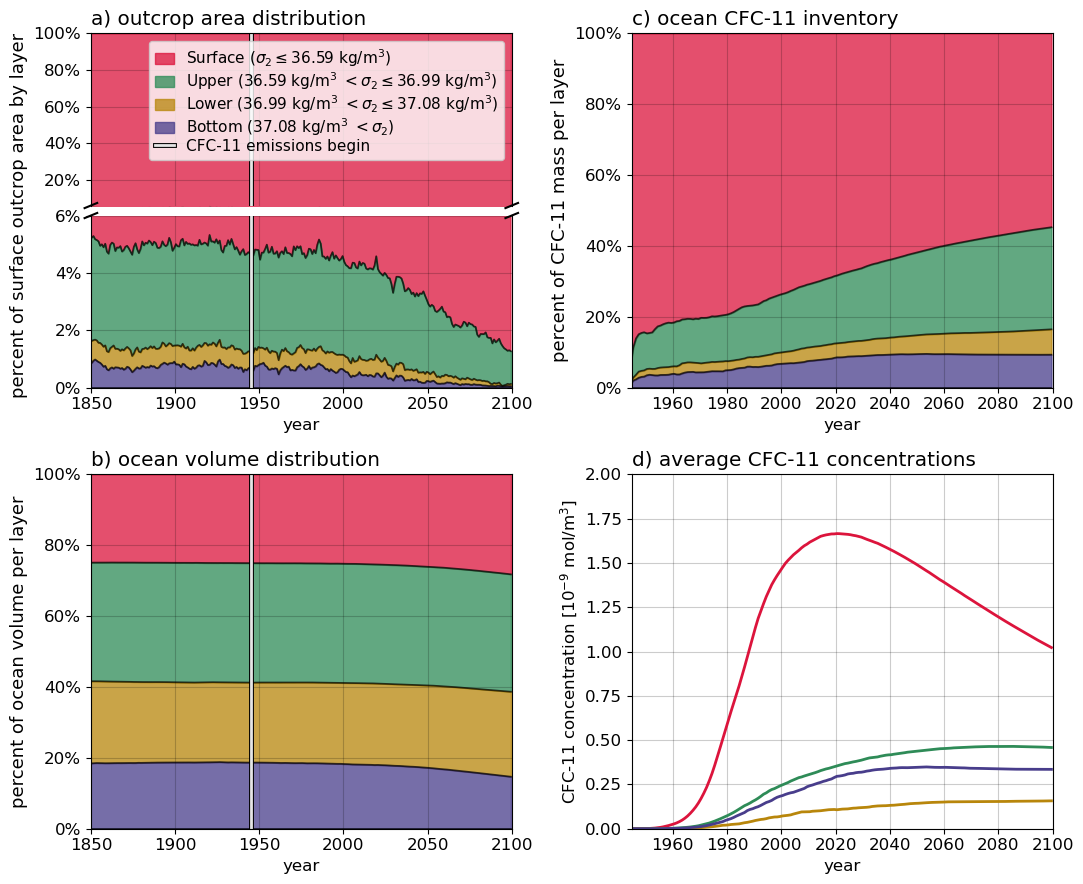

In [9]:
fig, axes = plt.subplots(2,2,figsize=(11,9))

ax = axes[0][0]
divider = make_axes_locatable(ax)
ax2 = divider.new_vertical(size="100%", pad=0.1)
fig.add_axes(ax2)
ax.spines['top'].set_visible(False)
ax2.tick_params(bottom=False, labelbottom=False)
ax2.spines['bottom'].set_visible(False)

sigma2_levs = np.round(moc_metrics.sigma2_moc_i[1:-1].values, 2)
sigma2_range = [
    rf"$\sigma_{{2}} \leq {sigma2_levs[0]}$ kg/m$^{{3}}$",
    rf"${sigma2_levs[0]}$ kg/m$^{{3}}$ $< \sigma_{{2}} \leq {sigma2_levs[1]}$ kg/m$^{{3}}$",
    rf"${sigma2_levs[1]}$ kg/m$^{{3}}$ $< \sigma_{{2}} \leq {sigma2_levs[2]}$ kg/m$^{{3}}$",
    rf"${sigma2_levs[2]}$ kg/m$^{{3}}$ $< \sigma_{{2}}$"
]

for k, (label, color) in enumerate(zip(layer_labels, layer_colors)):
    
    ax = axes.flatten()[0]
    outcrop_area = ds_inv.outcrop_area
    x = pad_years(outcrop_area.year)
    y1 = pad_array(100 - outcrop_area.isel(rho2_moc_l=slice(0,k)).sum("rho2_moc_l") / outcrop_area.sum("rho2_moc_l")*100)
    y2 = pad_array(100 - outcrop_area.isel(rho2_moc_l=slice(0,k+1)).sum("rho2_moc_l") / outcrop_area.sum("rho2_moc_l")*100)
    ax.fill_between(x, y1, y2, label=label, color=color, alpha=0.75)
    ax.plot(x, y2, color="k", lw=1.25, alpha=0.7)
    ax2.fill_between(x, y1, y2, label=f"{label} ({sigma2_range[k]})", color=color, alpha=0.75)
    ax2.plot(x, y2, color="k", lw=1.25, alpha=0.7)
    ax2.set_ylabel("percent of surface outcrop area by layer", fontsize=13, loc="top")
    ax2.set_title("a) outcrop area distribution", loc="left")

    ax = axes.flatten()[2]
    layer_inventory = ds_inv.volume
    x = pad_years(layer_inventory.year)
    y1 = pad_array(100 - layer_inventory.isel(rho2_moc_l=slice(0,k)).sum("rho2_moc_l") / layer_inventory.sum("rho2_moc_l")*100)
    y2 = pad_array(100 - layer_inventory.isel(rho2_moc_l=slice(0,k+1)).sum("rho2_moc_l") / layer_inventory.sum("rho2_moc_l")*100)    
    ax.fill_between(x, y1, y2, label=label, color=color, alpha=0.75)
    ax.plot(x, y2, color="k", lw=1.25, alpha=0.7)
    ax.set_ylabel("percent of ocean volume per layer", fontsize=13)
    ax.set_title("b) ocean volume distribution", loc="left")

    ax = axes.flatten()[1]
    cfc11_layer_inventory = ds_inv.cfc11_content
    x = pad_years(cfc11_layer_inventory.year)
    y1 = pad_array(100 - cfc11_layer_inventory.isel(rho2_moc_l=slice(0,k)).sum("rho2_moc_l") / cfc11_layer_inventory.sum("rho2_moc_l")*100)
    y2 = pad_array(100 - cfc11_layer_inventory.isel(rho2_moc_l=slice(0,k+1)).sum("rho2_moc_l") / cfc11_layer_inventory.sum("rho2_moc_l")*100)
    ax.fill_between(x, y1, y2, label=label, color=color, alpha=0.75)
    ax.plot(x, y2, color="k", lw=1.25, alpha=0.7)
    ax.set_ylabel("percent of CFC-11 mass per layer", fontsize=13)
    ax.set_title("c) ocean CFC-11 inventory", loc="left")
    
    ax = axes.flatten()[3]
    x = pad_years(cfc11_layer_inventory.year)
    y = pad_array((cfc11_layer_inventory/layer_inventory).isel(rho2_moc_l=k))
    ax.plot(x,y*1e9,color=color, lw=2)
    ax.set_ylabel(r"CFC-11 concentration [10$^{-9}$ mol/m$^{3}$]")
    ax.set_title("d) average CFC-11 concentrations", loc="left")

for ax in axes.flatten()[0:3]:
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

axes.flatten()[0].set_xlim(1850, 2100)
axes.flatten()[0].axvline(1945, color="w", alpha=0.9, lw=2, label="CFC-11 emissions begin", path_effects=[pe.Stroke(linewidth=3.5, foreground='k'), pe.Normal()])
ax2.axvline(1945, color="w", alpha=0.9, lw=2, label="CFC-11 emissions begin", path_effects=[pe.Stroke(linewidth=3.5, foreground='k'), pe.Normal()])
ax2.legend(fontsize=11, labelspacing=0.08, handlelength=1.2)
axes.flatten()[2].set_xlim(1850, 2100)
axes.flatten()[2].set_ylim(0, 100)
axes.flatten()[2].axvline(1945, color="w", alpha=0.9, lw=2, label="CFC-11 emissions begin", path_effects=[pe.Stroke(linewidth=3.5, foreground='k'), pe.Normal()])
axes.flatten()[1].set_xlim(1945, 2100)
axes.flatten()[3].set_xlim(1945, 2100)
axes.flatten()[3].set_ylim(0, 2)

ax = axes[0][0]
# From https://matplotlib.org/examples/pylab_examples/broken_axis.html
d = .015  # how big to make the diagonal lines in axes coordinates
# arguments to pass to plot, just so we don't keep repeating them
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
ax2.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax2.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal
kwargs.update(transform=ax.transAxes)  # switch to the bottom axes
ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal
ax.set_ylim(0, 6)
ax.set_xlim(1850, 2100)
ax2.set_ylim(6, 100)
ax2.set_xlim(1850, 2100)

for ax in axes.flatten():
    ax.grid(True, alpha=0.2, color="k")
    ax.set_xlabel("year")
ax2.grid(True, alpha=0.2, color="k")

plt.tight_layout()
plt.savefig("../figures/Fig3_layered_cfc11_inventory.png", bbox_inches="tight", dpi=300)